Aprendizado de variedades (Manifold Learning) com fluxo de clusterização distribuída por tipo de característica é mais informativo do que o UMAP para conjuntos de dados clínicos tabulares

Importando as Libraries

In [1]:
import sys
import os

# Ajusta o caminho para encontrar os módulos do FDC
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

print(f"Diretório atual: {current_dir}")
print(f"Diretório pai adicionado: {parent_dir}")

Diretório atual: c:\Católica\IA\Clinical-database\FDC_Low_Dimension\Jupyter Notebooks
Diretório pai adicionado: c:\Católica\IA\Clinical-database\FDC_Low_Dimension


In [2]:
import subprocess
import sys, os
sys.path.insert(0, os.path.abspath('../../FDC_Intermediate_Dimension'))

# Instala pacotes necessários que podem estar faltando
packages_to_install = ['yellowbrick']

for package in packages_to_install:
    try:
        __import__(package)
        print(f"✓ {package} já está instalado")
    except ImportError:
        print(f"Instalando {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])
        print(f"✓ {package} instalado com sucesso")

✓ yellowbrick já está instalado


In [3]:
import numpy as np                                #para operações matemáticas e processamento de matrizes(Euclidiana, Hamming e a Canberra Modificada)
import pandas as pd                               #manipulação de dados tabulares
from sklearn.preprocessing import StandardScaler  #escalonamento de dados para garantir que todas as variáveis contribuam igualmente
import matplotlib.pyplot as plt                   #para gerar todos os gráficos e mapas de calor
import seaborn as sns                             
%matplotlib inline                                
import warnings                                   #suprimir avisos de sistema durante a execução
warnings.filterwarnings('ignore')                 
import tensorflow as tf                           #bibliotecas de Deep Learning
from tensorflow import keras                      #Facilita criar redes neurais
import umap.umap_ as umap                         #importa o umap usado
%config InlineBackend.figure_format = 'svg'

In [4]:
#Importa os algorimos e medidas usadas no processo
from fdc.fdc import feature_clustering
from fdc.fdc import FDC, Clustering
from fdc.fdc import canberra_modified
modified_can = canberra_modified
from fdc.clustering import *

from sklearn import metrics
from sklearn.metrics import pairwise_distances
from sklearn.metrics import silhouette_score
from cluster_val import *

Importando os dados pré-processados

In [5]:
np.random.seed(42)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
data=pd.read_csv('../Datasets/heart_failure_clinical_records_dataset.csv')

In [6]:
np.random.seed(42)
data=data.sample(frac=1) #Embaralha o dataset
np.random.seed(42)
i=[x for x in range(299)]

data.set_index(pd.Series(i), inplace=True)

In [7]:
data.drop('DEATH_EVENT',axis=1,inplace=True)

UMAP nos dados originais

In [8]:
#Importa funções e classes do FDC
from fdc.fdc import feature_clustering
from fdc.fdc import FDC, Clustering
from fdc.fdc import canberra_modified
modified_can = canberra_modified
from fdc.clustering import *

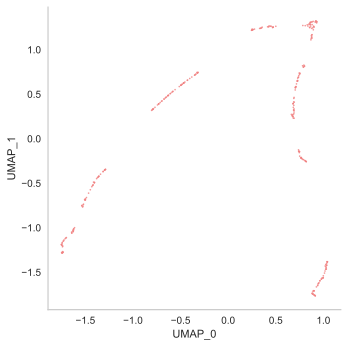

In [9]:
umap_emb=feature_clustering(15,0.1,'euclidean',data,True)

ANOVA test, Silhouette_score e Dunn index para os clusters do UMAP extraidos usando clustering K-means

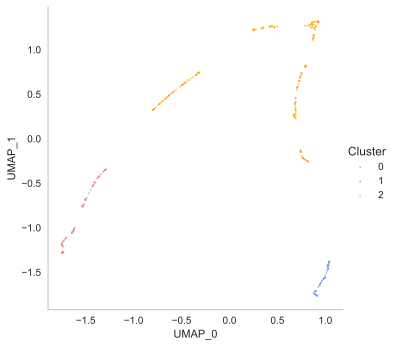

In [10]:
umap_clustering=Clustering(umap_emb,umap_emb,True)
umap_cluster_list,umap_cluster_counts=umap_clustering.K_means(3)

In [11]:
cont_list= ['age','creatinine_phosphokinase','ejection_fraction','platelets','serum_creatinine','serum_sodium','time']

ord_list= ['anaemia','diabetes','high_blood_pressure','sex','smoking']

nom_list= []

In [12]:
### ANOVA TEST 


data['Cluster']=umap_cluster_list
test_results={}
c_names=data.columns
from scipy.stats import f_oneway
for i in c_names[:-1]:
    for j in range(len(np.unique(data.Cluster))):
        var_name="c_"+str(j)
        myVars = vars()
        myVars[var_name]=list(data[i][data["Cluster"]==j])
    
    stats,p_val=f_oneway(c_0,c_1,c_2)
    test_results[i]=stats,float("{:.4f}".format(p_val))

test_results=pd.DataFrame.from_dict(test_results, orient='index', columns=["stats","p_value"])
test_column_list=test_results.index[test_results["p_value"]<0.05].to_list()
ord_count=nom_count=cont_count=0
for i in test_column_list:
    if i in ord_list:
        ord_count+=1
    elif i in nom_list:
        nom_count+=1
    elif i in cont_list:
        cont_count+=1
print('percentage of all features having p-value less than 0.05: ',float("{:.2f}".format((len(test_column_list)/(len(c_names)-1))*100)),'%')
print('percentage of ordinal features having p-value less than 0.05: ',(ord_count/len(ord_list))*100,'%')
#print('percentage of  nominal features having p-value less than 0.05: ',(nom_count/len(nom_list))*100,'%')
print('percentage of continous features having p-value less than 0.05: ',(cont_count/len(cont_list))*100,'%')

percentage of all features having p-value less than 0.05:  8.33 %
percentage of ordinal features having p-value less than 0.05:  0.0 %
percentage of continous features having p-value less than 0.05:  14.285714285714285 %


In [13]:
silhouette_score(umap_emb, umap_cluster_list, metric='euclidean')

0.7215150593855391

Visualizar Silhouette score (Pode-se escolher o números de clusters baseados no resultado)

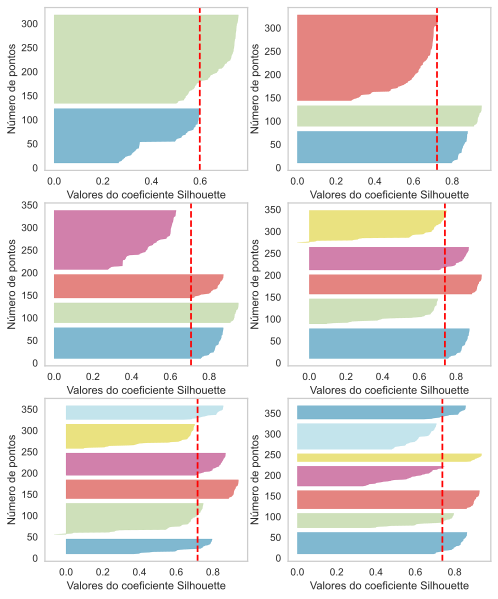

In [14]:
Silhouette_visual(umap_emb)

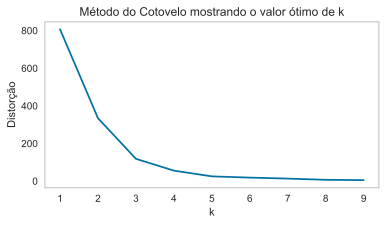

In [15]:
elbow_plot(umap_emb)

In [16]:
dunn_index(cluster_wise_df(umap_emb,umap_cluster_list))

0.5718464185734525

ANOVA test, Silhouette_score e Dunn index para os clusters do UMAP extraidos usando clustering Aglomerativo

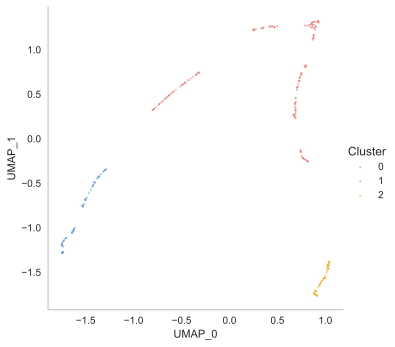

In [17]:
umap_cluster_list_agglo,umap_cluster_counts_agglo=umap_clustering.Agglomerative(3,'euclidean','ward')

In [18]:
### ANOVA TEST

data['Cluster']=umap_cluster_list_agglo
test_results={}
c_names=data.columns
from scipy.stats import f_oneway
for i in c_names[:-1]:
    for j in range(len(np.unique(data.Cluster))):
        var_name="c_"+str(j)
        myVars = vars()
        myVars[var_name]=list(data[i][data["Cluster"]==j])
    
    stats,p_val=f_oneway(c_0,c_1,c_2)
    test_results[i]=stats,float("{:.4f}".format(p_val))

test_results=pd.DataFrame.from_dict(test_results, orient='index', columns=["stats","p_value"])
test_column_list=test_results.index[test_results["p_value"]<0.05].to_list()
ord_count=nom_count=cont_count=0
for i in test_column_list:
    if i in ord_list:
        ord_count+=1
    elif i in nom_list:
        nom_count+=1
    elif i in cont_list:
        cont_count+=1
print('percentage of all features having p-value less than 0.05: ',float("{:.2f}".format((len(test_column_list)/(len(c_names)-1))*100)),'%')
print('percentage of ordinal features having p-value less than 0.05: ',(ord_count/len(ord_list))*100,'%')
#print('percentage of  nominal features having p-value less than 0.05: ',(nom_count/len(nom_list))*100,'%')
print('percentage of continous features having p-value less than 0.05: ',(cont_count/len(cont_list))*100,'%')

percentage of all features having p-value less than 0.05:  8.33 %
percentage of ordinal features having p-value less than 0.05:  0.0 %
percentage of continous features having p-value less than 0.05:  14.285714285714285 %


In [19]:
silhouette_score(umap_emb, umap_cluster_list_agglo, metric='euclidean')

0.7208239842145473

In [20]:
dunn_index(cluster_wise_df(umap_emb,umap_cluster_list_agglo))

0.4100306336964232

ANOVA test, Silhouette_score e Dunn index para os clusters do UMAP extraidos usando clustering DBSCAN 

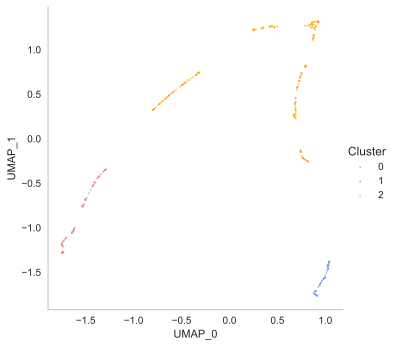

In [21]:
umap_cluster_list_dbscan,umap_cluster_counts_dbscan=umap_clustering.DBSCAN(0.9,20)

In [22]:
### ANOVA TEST

data['Cluster']=umap_cluster_list_dbscan
test_results={}
c_names=data.columns
from scipy.stats import f_oneway
for i in c_names[:-1]:
    for j in range(len(np.unique(data.Cluster))):#add -1 if there is noise otherwise not necessary------applicable only for DBSCAN
        var_name="c_"+str(j)
        myVars = vars()
        myVars[var_name]=list(data[i][data["Cluster"]==j])
    
    stats,p_val=f_oneway(c_0,c_1,c_2)
    test_results[i]=stats,float("{:.4f}".format(p_val))

test_results=pd.DataFrame.from_dict(test_results, orient='index', columns=["stats","p_value"])
test_column_list=test_results.index[test_results["p_value"]<0.05].to_list()
ord_count=nom_count=cont_count=0
for i in test_column_list:
    if i in ord_list:
        ord_count+=1
    elif i in nom_list:
        nom_count+=1
    elif i in cont_list:
        cont_count+=1
print('percentage of all features having p-value less than 0.05: ',float("{:.2f}".format((len(test_column_list)/(len(c_names)-1))*100)),'%')
print('percentage of ordinal features having p-value less than 0.05: ',(ord_count/len(ord_list))*100,'%')
#print('percentage of  nominal features having p-value less than 0.05: ',(nom_count/len(nom_list))*100,'%')
print('percentage of continous features having p-value less than 0.05: ',(cont_count/len(cont_list))*100,'%')

percentage of all features having p-value less than 0.05:  8.33 %
percentage of ordinal features having p-value less than 0.05:  0.0 %
percentage of continous features having p-value less than 0.05:  14.285714285714285 %


In [23]:
#Remove os indices considerados ruídos pelo algoritmo
non_noise_indices= np.where(np.array(umap_cluster_list_dbscan)!=-1)
umap_emb= umap_emb.iloc[non_noise_indices]
#FDC_emb_low= FDC_emb_low.iloc[non_noise_indices]
umap_cluster_list_dbscan= np.array(umap_cluster_list_dbscan)[non_noise_indices]

In [24]:
silhouette_score(umap_emb, umap_cluster_list_dbscan, metric='euclidean')

0.7215150593855391

In [25]:
dunn_index(cluster_wise_df(umap_emb,umap_cluster_list_dbscan))

0.5718464185734525

Dividindo as variaveis
- cont_list = contínuas
- ord_list = ordinais

In [26]:
cont_list= ['age','creatinine_phosphokinase','ejection_fraction','platelets','serum_creatinine','serum_sodium','time']

ord_list= ['anaemia','diabetes','high_blood_pressure','sex','smoking']

In [27]:
len(ord_list)

5

In [28]:
len(cont_list)

7

Aplicando FDC nos dados originais

In [29]:
from fdc.fdc import feature_clustering
from fdc.fdc import FDC, Clustering
from fdc.fdc import canberra_modified
modified_can = canberra_modified

FDC.normalize (init): 0.00000 / 0.000s
FDC.normalize (clustering CONT): 0.28125 / 0.281s
FDC.normalize (clustering ORD): 1.15625 / 1.438s
FDC.normalize (clustering NOM): 0.00000 / 1.438s
FDC.normalize (concat): 0.00000 / 1.438s
FDC.normalize (umap 5 -> 2): 0.26562 / 1.703s
FDC.normalize (array -> DataFrame): 0.00000 / 1.703s


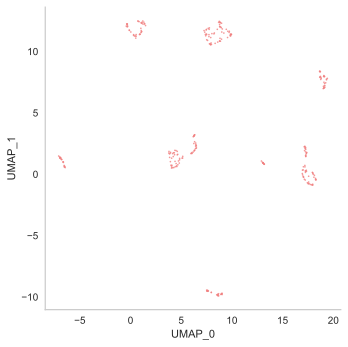

FDC.normalize (plotting): 0.29688 / 2.000s
FDC.normalize (array -> DataFrame): 0.00000 / 2.000s
FDC.normalize (total): 0.00000 / 2.000s


In [30]:
fdc = FDC(clustering_cont=Clustering('euclidean',15,0.1) #número de vizinhos e parâmetro de densidade
          , clustering_ord=Clustering(modified_can,15,0.1,max_components=1) #usa Canberra modificada que é mais sensível a valores pequenos
          , visual=True
          , use_pandas_output=True
          , with_2d_embedding=True #projeção 2D
          )

fdc.selectFeatures(continueous=cont_list, ordinal=ord_list) #diz ao modelo quais variáveis são contínuas e quais são ordinais

FDC_emb_high,FDC_emb_low = fdc.normalize(data,
                                        n_neighbors=15,         #numero de vizinhos
                                        min_dist=0.1,           #o quão proximo os clusters vão ficar
                                        cont_list=cont_list,
                                        ord_list=ord_list,
                                        with_2d_embedding=True, #Gera duas representações, uma de alta e outra de baixa dimensão
                                        visual=True)

ANOVA test, Silhouette_score e Dunn index para os clusters FDC (de dimensão intermediaria) extraídos usando k-means

In [31]:
from fdc.clustering import Clustering

In [32]:
FDC_emb_low.rename(columns={"UMAP_0": "FDC_0", "UMAP_1": "FDC_1"},inplace=True)

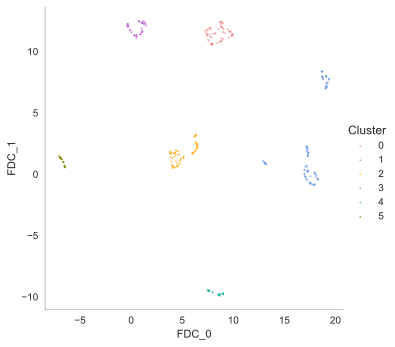

In [33]:
clustering=Clustering(FDC_emb_low,FDC_emb_low,True)
cluster_list,cluster_counts=clustering.K_means(6)

In [34]:
### ANOVA TEST

data['Cluster']=cluster_list
test_results={}
c_names=data.columns
from scipy.stats import f_oneway
for i in c_names[:-1]:
    for j in range(len(np.unique(data.Cluster))):#add -1 if there is noise otherwise not necessary------applicable only for DBSCAN
        var_name="c_"+str(j)
        myVars = vars()
        myVars[var_name]=list(data[i][data["Cluster"]==j])
    
    stats,p_val=f_oneway(c_0,c_1,c_2,c_3,c_4,c_5)
    test_results[i]=stats,float("{:.4f}".format(p_val))

test_results=pd.DataFrame.from_dict(test_results, orient='index', columns=["stats","p_value"])
test_column_list=test_results.index[test_results["p_value"]<0.05].to_list()
ord_count=nom_count=cont_count=0
for i in test_column_list:
    if i in ord_list:
        ord_count+=1
    elif i in nom_list:
        nom_count+=1
    elif i in cont_list:
        cont_count+=1
print('percentage of all features having p-value less than 0.05: ',float("{:.2f}".format((len(test_column_list)/(len(c_names)-1))*100)),'%')
print('percentage of ordinal features having p-value less than 0.05: ',(ord_count/len(ord_list))*100,'%')
#print('percentage of  nominal features having p-value less than 0.05: ',(nom_count/len(nom_list))*100,'%')
print('percentage of continous features having p-value less than 0.05: ',(cont_count/len(cont_list))*100,'%')

percentage of all features having p-value less than 0.05:  41.67 %
percentage of ordinal features having p-value less than 0.05:  80.0 %
percentage of continous features having p-value less than 0.05:  14.285714285714285 %


In [35]:
silhouette_score(FDC_emb_low, cluster_list, metric='euclidean')

0.7930905551195351

In [36]:
dunn_index(cluster_wise_df(FDC_emb_low,cluster_list))

0.6933917924482652

Visualizando Shilhouette score para FDC embedding de baixa dimensão

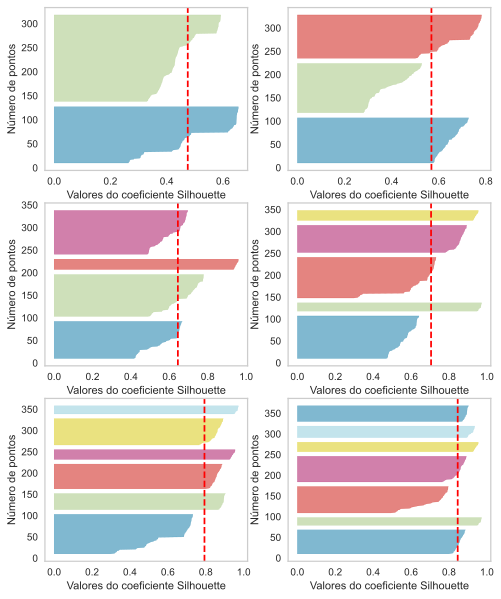

In [37]:
Silhouette_visual(FDC_emb_low)

Elbow plot para FDC embedding de baixa dimensão

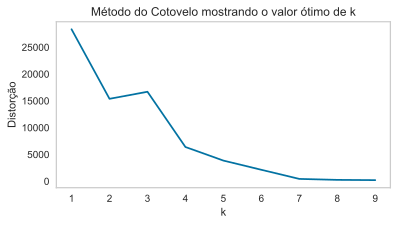

In [38]:
elbow_plot(FDC_emb_low)

ANOVA test, Silhouette_score e Dunn index para os clusters FDC (de dimensão intermediaria) extraídos usando clustering aglomerativo

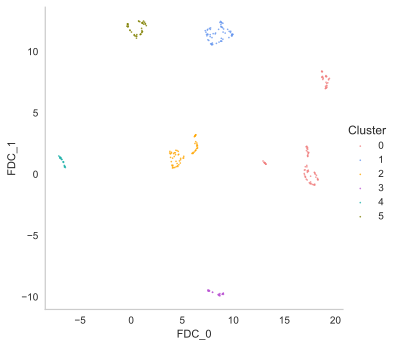

In [39]:
cluster_list_agglo,cluster_counts_agglo=clustering.Agglomerative(6,'euclidean','ward')

In [40]:
### ANOVA TEST

data['Cluster']=cluster_list_agglo
test_results={}
c_names=data.columns
from scipy.stats import f_oneway
for i in c_names[:-1]:
    for j in range(len(np.unique(data.Cluster))):#add -1 if there is noise otherwise not necessary------applicable only for DBSCAN
        var_name="c_"+str(j)
        myVars = vars()
        myVars[var_name]=list(data[i][data["Cluster"]==j])
    
    stats,p_val=f_oneway(c_0,c_1,c_2,c_3,c_4,c_5)
    test_results[i]=stats,float("{:.4f}".format(p_val))

test_results=pd.DataFrame.from_dict(test_results, orient='index', columns=["stats","p_value"])
test_column_list=test_results.index[test_results["p_value"]<0.05].to_list()
ord_count=nom_count=cont_count=0
for i in test_column_list:
    if i in ord_list:
        ord_count+=1
    elif i in nom_list:
        nom_count+=1
    elif i in cont_list:
        cont_count+=1
print('percentage of all features having p-value less than 0.05: ',float("{:.2f}".format((len(test_column_list)/(len(c_names)-1))*100)),'%')
print('percentage of ordinal features having p-value less than 0.05: ',(ord_count/len(ord_list))*100,'%')
#print('percentage of  nominal features having p-value less than 0.05: ',(nom_count/len(nom_list))*100,'%')
print('percentage of continous features having p-value less than 0.05: ',(cont_count/len(cont_list))*100,'%')

percentage of all features having p-value less than 0.05:  41.67 %
percentage of ordinal features having p-value less than 0.05:  80.0 %
percentage of continous features having p-value less than 0.05:  14.285714285714285 %


In [41]:
silhouette_score(FDC_emb_low, cluster_list_agglo, metric='euclidean')

0.795592970931788

In [42]:
dunn_index(cluster_wise_df(FDC_emb_low,cluster_list_agglo))

0.8000174450228357

ANOVA test, Silhouette_score e Dunn index para os clusters FDC (de dimensão intermediaria) extraídos usando clustering do DBSCAN

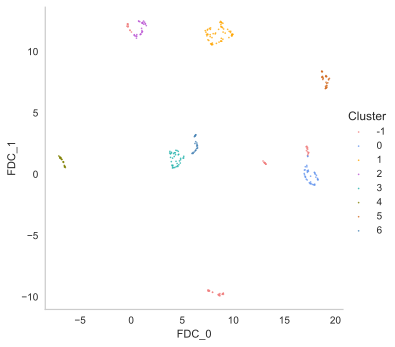

In [43]:
cluster_list_dbscan,cluster_counts_dbscan=clustering.DBSCAN(0.9,20)

In [44]:
### ANOVA TEST


data['Cluster']=cluster_list_dbscan
test_results={}
c_names=data.columns
from scipy.stats import f_oneway
for i in c_names[:-1]:
    for j in range(len(np.unique(data.Cluster))-1):#add -1 if there is noise otherwise not necessary------applicable only for DBSCAN
        var_name="c_"+str(j)
        myVars = vars()
        myVars[var_name]=list(data[i][data["Cluster"]==j])
    
    stats,p_val=f_oneway(c_0,c_1,c_2,c_3,c_4,c_5,c_6)
    test_results[i]=stats,float("{:.4f}".format(p_val))

test_results=pd.DataFrame.from_dict(test_results, orient='index', columns=["stats","p_value"])
test_column_list=test_results.index[test_results["p_value"]<0.05].to_list()
ord_count=nom_count=cont_count=0
for i in test_column_list:
    if i in ord_list:
        ord_count+=1
    elif i in nom_list:
        nom_count+=1
    elif i in cont_list:
        cont_count+=1
print('percentage of all features having p-value less than 0.05: ',float("{:.2f}".format((len(test_column_list)/(len(c_names)-1))*100)),'%')
print('percentage of ordinal features having p-value less than 0.05: ',(ord_count/len(ord_list))*100,'%')
#print('percentage of  nominal features having p-value less than 0.05: ',(nom_count/len(nom_list))*100,'%')
print('percentage of continous features having p-value less than 0.05: ',(cont_count/len(cont_list))*100,'%')

percentage of all features having p-value less than 0.05:  33.33 %
percentage of ordinal features having p-value less than 0.05:  60.0 %
percentage of continous features having p-value less than 0.05:  14.285714285714285 %


In [45]:
cluster_counts_dbscan

array([60, 40, 59, 28, 38, 20, 29, 25])

In [46]:
#removing noise indices from the embeddings
non_noise_indices= np.where(np.array(cluster_list_dbscan)!=-1)
FDC_emb_high= FDC_emb_high.iloc[non_noise_indices]
FDC_emb_low= FDC_emb_low.iloc[non_noise_indices]
cluster_list_dbscan= np.array(cluster_list_dbscan)[non_noise_indices]

In [47]:
silhouette_score(FDC_emb_low, cluster_list_dbscan, metric='euclidean')

0.8704943041165095

In [48]:
dunn_index(cluster_wise_df(FDC_emb_low,cluster_list_dbscan))

2.130639986590949